In [271]:
%%writefile single.py
import numpy as np
import matplotlib.pyplot as plt
import time

t0 = time.time()
r = 0.1
x_0 = 0.1
n = 200
m = 200

def x(n):
    result = [x_0,]
    for i in range(1, n, 1):
        result.append(r * result[i - 1] * (1 - result[i - 1]))
    return result
    
x_matrix = np.empty((0, m))
r_matrix = np.empty((0, m))
r_arr = np.linspace(0, 4, 5000)
for r in r_arr:
    x_matrix = np.append(x_matrix, np.array([x(m + n)[n:]]), axis=0)
    r_matrix = np.append(r_matrix, [np.dot(np.ones(m), r)], axis=0)
    
t1 = time.time()
print('Time: {}'.format(t1 - t0))

Overwriting single.py


In [274]:
%%writefile parallel.py
from mpi4py import MPI
import time
import math
import numpy as np
import matplotlib.pyplot as plt


t0 = time.time()
n = 200
m = 200
x_0 = 0.1
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
nprocs = comm.Get_size()

def x(n):
    result = [x_0,]
    for i in range(1, n, 1):
        result.append(r * result[i - 1] * (1 - result[i - 1]))
    return result

if rank == 0:
    r_arr = np.linspace(0, 4, 5000)

    # determine the size of each sub-task
    ave, res = divmod(r_arr.size, nprocs)
    counts = [ave + 1 if p < res else ave for p in range(nprocs)]

    # determine the starting and ending indices of each sub-task
    starts = [sum(counts[:p]) for p in range(nprocs)]
    ends = [sum(counts[:p+1]) for p in range(nprocs)]

    # converts data into a list of arrays 
    r_arr = [r_arr[starts[p]:ends[p]] for p in range(nprocs)]
else:
    r_arr = None

r_arr = comm.scatter(r_arr, root=0)

x_matrix = np.empty((0, m))
r_matrix = np.empty((0, m))
for r in r_arr:
    x_matrix = np.append(x_matrix, np.array([x(m + n)[n:]]), axis=0)
    r_matrix = np.append(r_matrix, [np.dot(np.ones(m), r)], axis=0)

x_matrix = comm.gather(x_matrix, root=0)
r_matrix = comm.gather(r_matrix, root=0)

if (rank == 0):
    t1 = time.time()
    with open("data.txt", "a") as myfile:
        myfile.write(str(t1 - t0) + ' ')
    # print('Time: {}'.format(t1 - t0))



Overwriting parallel.py


In [402]:
!mpirun -n 1 --allow-run-as-root python3 parallel.py

In [403]:
!mpirun -n 2 --allow-run-as-root python3 parallel.py

In [404]:
!mpirun -n 3 --allow-run-as-root python3 parallel.py

In [405]:
!mpirun -n 4 --allow-run-as-root python3 parallel.py

In [406]:
!mpirun -n 5 --allow-run-as-root python3 parallel.py

In [407]:
!mpirun -n 6 --allow-run-as-root python3 parallel.py

In [408]:
!mpirun -n 7 --allow-run-as-root python3 parallel.py

In [409]:
!mpirun -n 8 --allow-run-as-root python3 parallel.py

In [410]:
!python3 single.py

Time: 2.5350759029388428


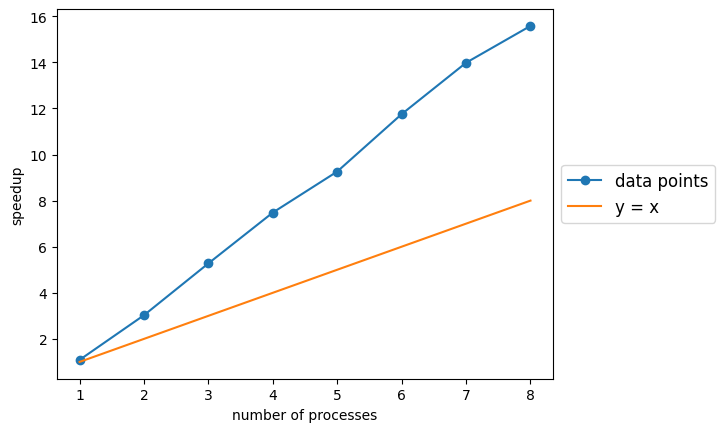

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = []
with open('data.txt', 'r') as myfile:
    data = myfile.readlines()[0].split(' ')
    data = np.array(list((map(float, data[:-1]))))
single_data = 2.837002

plt.plot(np.arange(1, 9, 1), single_data / data, '-o', label='data points')
plt.plot(np.arange(1, 9, 1), np.arange(1, 9, 1), '-', label='y = x')
plt.xlabel('number of processes')
plt.ylabel('speedup')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), prop={'size': 12})
plt.savefig('plot speedup vs. number of processes.png', format='png', dpi=300, bbox_inches='tight')

In [401]:
open('data.txt', 'w').close()